### **Tesla Closing Price vs. 5-Day Moving Average Model**
------------------------
**Sharah Ahmed**

In [65]:
# https://drive.google.com/file/d/1oqpMjUUowfvkImPBeAE9GwnIl2_Z1Wme/view
!gdown 1D6ZuJvol7gVeyEHaOhBpHPZD8MlxDLXK

Downloading...
From: https://drive.google.com/uc?id=1D6ZuJvol7gVeyEHaOhBpHPZD8MlxDLXK
To: /content/ctheatingoilregionalretailpricespdf.csv
100% 6.17k/6.17k [00:00<00:00, 17.8MB/s]


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**READ THE DATA**

In [67]:
df = pd.read_csv('/content/Download Data - STOCK_US_XNAS_TSLA (2).csv')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    253 non-null    object 
 1   Open    253 non-null    float64
 2   High    253 non-null    float64
 3   Low     253 non-null    float64
 4   Close   253 non-null    float64
 5   Volume  253 non-null    object 
dtypes: float64(4), object(2)
memory usage: 12.0+ KB


In [69]:
df.head(10)

,Date,Open,High,Low,Close,Volume
0,10/25/2024,256.01,269.49,255.32,269.19,"161,611,906"
1,10/24/2024,244.68,262.12,242.65,260.48,"204,491,906"
2,10/23/2024,217.13,218.72,212.11,213.65,"80,938,891"
3,10/22/2024,217.31,218.22,215.26,217.97,"43,268,738"
4,10/21/2024,218.90,220.48,215.73,218.85,"47,328,992"
5,10/18/2024,220.71,222.28,219.23,220.70,"49,611,871"
6,10/17/2024,221.59,222.08,217.90,220.89,"50,791,781"
7,10/16/2024,221.40,222.82,218.93,221.33,"49,632,820"
8,10/15/2024,220.01,224.26,217.12,219.57,"62,988,793"
9,10/14/2024,220.13,221.91,213.74,219.16,"86,291,922"


**CLEAN THE DATA**

In [70]:
# old column names
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

<Axes: >

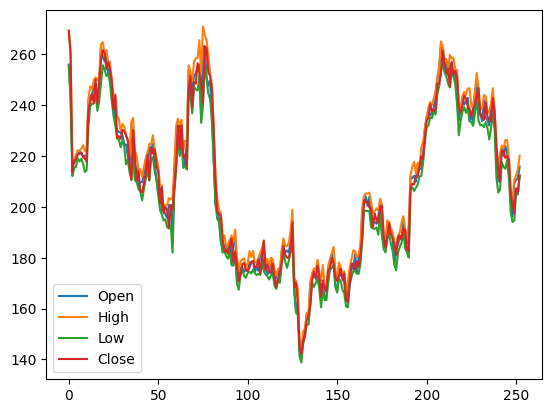

In [71]:
df.plot()

In [72]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume
0,2024-10-25,256.01,269.49,255.32,269.19,"161,611,906"
1,2024-10-24,244.68,262.12,242.65,260.48,"204,491,906"
2,2024-10-23,217.13,218.72,212.11,213.65,"80,938,891"
3,2024-10-22,217.31,218.22,215.26,217.97,"43,268,738"
4,2024-10-21,218.90,220.48,215.73,218.85,"47,328,992"


Set date as index

In [73]:
df.index = df['Date']

In [74]:
del df['Date']

In [75]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2024-10-25,256.01,269.49,255.32,269.19,"161,611,906"
2024-10-24,244.68,262.12,242.65,260.48,"204,491,906"
2024-10-23,217.13,218.72,212.11,213.65,"80,938,891"
2024-10-22,217.31,218.22,215.26,217.97,"43,268,738"
2024-10-21,218.90,220.48,215.73,218.85,"47,328,992"


**EXPLORE THE DATA**

Basic plot

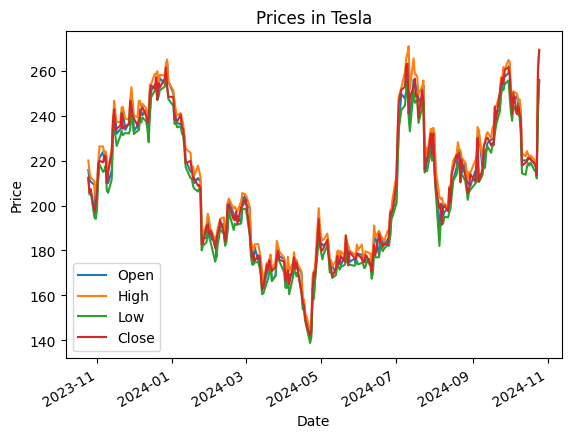

In [76]:
df.plot()
plt.title('Prices in Tesla')
plt.ylabel('Price')
plt.xlabel('Date')
plt.show()

Summary of stats

In [77]:
df.describe()

,Open,High,Low,Close
count,253.000000,253.000000,253.000000,253.000000
mean,208.527431,212.683992,204.325731,208.577273
std,29.974596,30.546339,29.291560,30.053438
min,140.560000,144.440000,138.800000,142.050000
25%,182.000000,184.590000,177.000000,180.010000
50%,210.590000,214.890000,205.970000,209.140000
75%,234.560000,238.990000,231.900000,235.600000
max,263.660000,271.000000,257.860000,269.190000


Boxplot

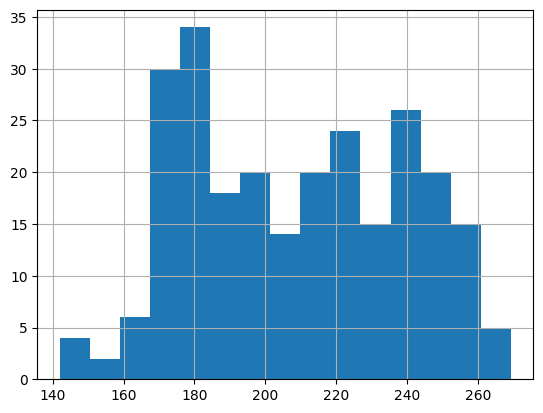

In [78]:
df['Close'].hist(bins=15)
plt.show()

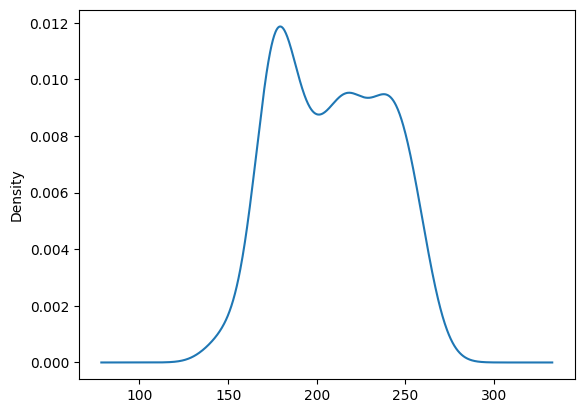

In [79]:
df['Close'].plot.kde()
plt.show()

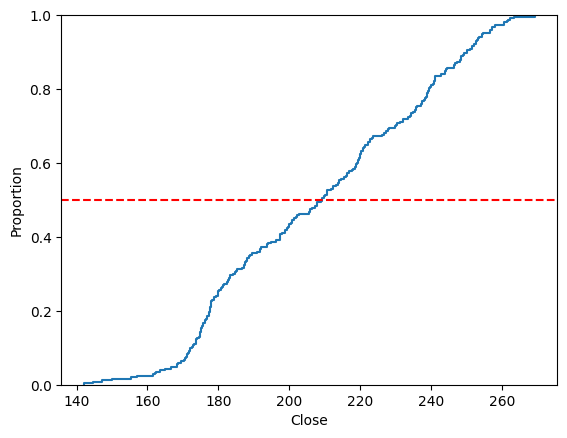

In [80]:
# prompt: make a cdf plot of the df['Close'] column and add a horizontal line at proportion = 0.5

import seaborn as sns

# Create the CDF plot
sns.ecdfplot(df['Close'])

# Add a horizontal line at proportion = 0.5
plt.axhline(y=0.5, color='red', linestyle='dashed')

# Show the plot
plt.show()

**MAKE A MOVING AVERAGE MODEL**

In [81]:
tmp = df['Close']
tmp = pd.DataFrame(tmp)
tmp

,Close
Date,
2024-10-25,269.19
2024-10-24,260.48
2024-10-23,213.65
2024-10-22,217.97
2024-10-21,218.85
...,...
2023-10-31,200.84
2023-10-30,197.36
2023-10-27,207.30


In [82]:
df['rolling5_close'] = df['Close'].rolling(window=5).mean()
df.head()

,Open,High,Low,Close,Volume,rolling5_close
Date,,,,,,
2024-10-25,256.01,269.49,255.32,269.19,"161,611,906",NaN
2024-10-24,244.68,262.12,242.65,260.48,"204,491,906",NaN
2024-10-23,217.13,218.72,212.11,213.65,"80,938,891",NaN
2024-10-22,217.31,218.22,215.26,217.97,"43,268,738",NaN
2024-10-21,218.90,220.48,215.73,218.85,"47,328,992",236.028


In [83]:
(269.19 + 260.48 + 213.65)/3

247.77333333333334

In [84]:
df['5_day_MA_correct'] = df['Close'].shift(1).rolling(window=5).mean()
df.head()

,Open,High,Low,Close,Volume,rolling5_close,5_day_MA_correct
Date,,,,,,,
2024-10-25,256.01,269.49,255.32,269.19,"161,611,906",NaN,NaN
2024-10-24,244.68,262.12,242.65,260.48,"204,491,906",NaN,NaN
2024-10-23,217.13,218.72,212.11,213.65,"80,938,891",NaN,NaN
2024-10-22,217.31,218.22,215.26,217.97,"43,268,738",NaN,NaN
2024-10-21,218.90,220.48,215.73,218.85,"47,328,992",236.028,NaN


In [85]:
tmp.dropna(inplace=True)

**EVALUATE THE MODEL**

Scatterplot (actual vs. predicted)

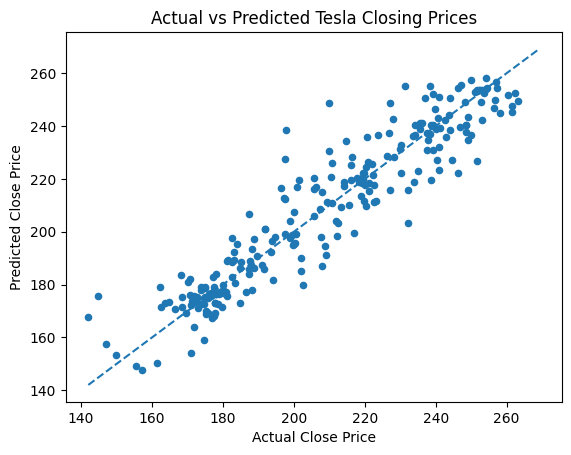

In [86]:
# Scatterplot of actual vs predicted
df.plot.scatter(x='Close', y='5_day_MA_correct')

# Add 45° reference line
plt.plot([df['Close'].min(), df['Close'].max()],
         [df['Close'].min(), df['Close'].max()],
         linestyle='--')

plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted Tesla Closing Prices')

plt.show()

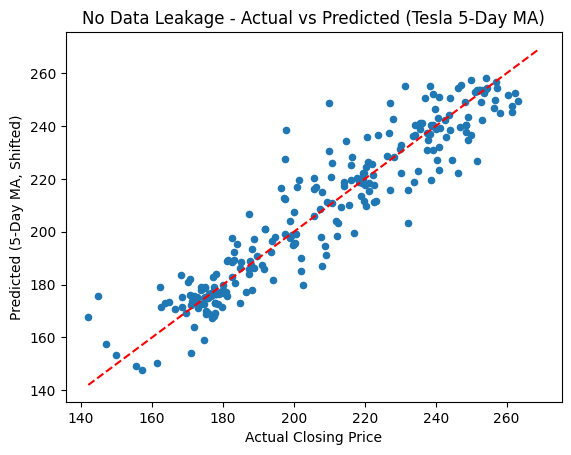

In [87]:
# Scatterplot of actual (Close) vs predicted (shifted moving average)
df.plot.scatter(x='Close', y='5_day_MA_correct')

# Add 45° reference line
plt.plot([df['Close'].min(), df['Close'].max()],
         [df['Close'].min(), df['Close'].max()],
         color='red', linestyle='dashed')

plt.title('No Data Leakage - Actual vs Predicted (Tesla 5-Day MA)')
plt.xlabel('Actual Closing Price')
plt.ylabel('Predicted (5-Day MA, Shifted)')
plt.show()

**Evaluate the error metrics**

In [88]:
df_eval = df.dropna(subset=['Close', '5_day_MA_correct'])

# Define actual and predicted
actual = df_eval['Close']
predicted = df_eval['5_day_MA_correct']

**Time Series Plots**

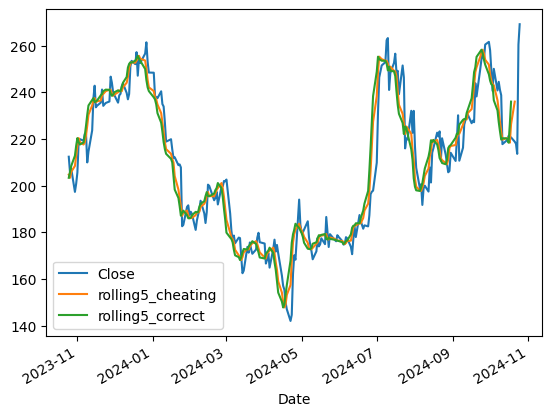

In [89]:
tmp['rolling5_cheating'] = tmp['Close'].rolling(window=5).mean()
tmp['rolling5_correct'] = tmp['rolling5_cheating'].shift(1)
tmp.plot()
plt.show()

In [90]:
df.head()

,Open,High,Low,Close,Volume,rolling5_close,5_day_MA_correct
Date,,,,,,,
2024-10-25,256.01,269.49,255.32,269.19,"161,611,906",NaN,NaN
2024-10-24,244.68,262.12,242.65,260.48,"204,491,906",NaN,NaN
2024-10-23,217.13,218.72,212.11,213.65,"80,938,891",NaN,NaN
2024-10-22,217.31,218.22,215.26,217.97,"43,268,738",NaN,NaN
2024-10-21,218.90,220.48,215.73,218.85,"47,328,992",236.028,NaN


In [91]:
myWindow = 5

In [92]:
myWindow = 5

df['PRED'] = df['Close'].shift(1).rolling(window=myWindow).mean()
df.head(15)

,Open,High,Low,Close,Volume,rolling5_close,5_day_MA_correct,PRED
Date,,,,,,,,
2024-10-25,256.01,269.49,255.32,269.19,"161,611,906",NaN,NaN,NaN
2024-10-24,244.68,262.12,242.65,260.48,"204,491,906",NaN,NaN,NaN
2024-10-23,217.13,218.72,212.11,213.65,"80,938,891",NaN,NaN,NaN
2024-10-22,217.31,218.22,215.26,217.97,"43,268,738",NaN,NaN,NaN
2024-10-21,218.90,220.48,215.73,218.85,"47,328,992",236.028,NaN,NaN
2024-10-18,220.71,222.28,219.23,220.70,"49,611,871",226.330,236.028,236.028
2024-10-17,221.59,222.08,217.90,220.89,"50,791,781",218.412,226.330,226.330
2024-10-16,221.40,222.82,218.93,221.33,"49,632,820",219.948,218.412,218.412
2024-10-15,220.01,224.26,217.12,219.57,"62,988,793",220.268,219.948,219.948


In [93]:
df.dropna(inplace=True)

In [94]:
df.tail()

,Open,High,Low,Close,Volume,rolling5_close,5_day_MA_correct,PRED
Date,,,,,,,,
2023-10-31,196.12,202.80,194.07,200.84,"118,068,305",212.848,217.116,217.116
2023-10-30,209.28,210.88,194.67,197.36,"136,448,188",208.466,212.848,212.848
2023-10-27,210.60,212.41,205.77,207.30,"94,881,172",205.934,208.466,208.466
2023-10-26,211.32,214.80,204.88,205.76,"115,112,602",203.384,205.934,205.934
2023-10-25,215.88,220.10,212.20,212.42,"107,065,102",204.736,203.384,203.384


In [95]:
# specify actual and pred columns
actual = df['Close']
predicted = df['PRED']

In [96]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Define your actual and predicted columns
actual = df['Close'].dropna()
predicted = df['PRED'].dropna()

# Align them so they have the same index (important after shifting)
actual, predicted = actual.align(predicted, join='inner')

# R2
r2 = r2_score(actual, predicted)

# MAE
mae = mean_absolute_error(actual, predicted)

# MAPE
mape = mean_absolute_percentage_error(actual, predicted)

# Bias
bias = np.mean(predicted - actual)

# Print results
print("Evaluation metrics for 5-day moving average (no data leakage):")
print(f"- R2:   {r2:.4f}")
print(f"- MAE:  {mae:.4f}")
print(f"- MAPE: {mape:.4f}")
print(f"- Bias: {bias:.4f}")


Evaluation metrics for 5-day moving average (no data leakage):
- R2:   0.8798
- MAE:  7.6153
- MAPE: 0.0372
- Bias: 0.2376


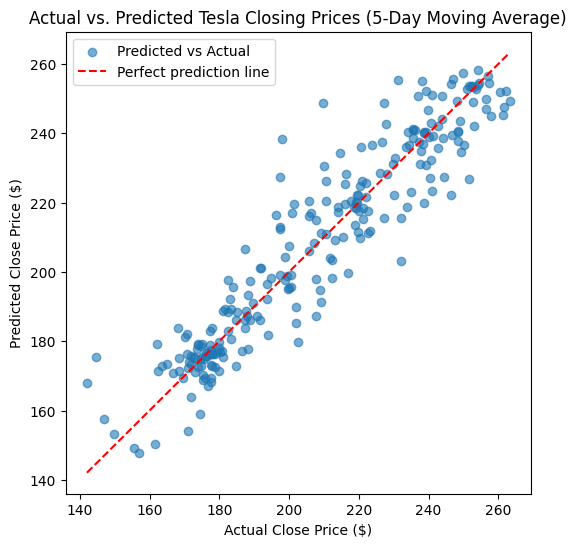

In [97]:
# Scatterplot of actual vs. predicted Tesla closing prices
plt.figure(figsize=(6,6))
plt.scatter(x=actual, y=predicted, alpha=0.6, label='Predicted vs Actual')

# Add the 45-degree line (perfect prediction)
plt.plot([min(actual), max(actual)],
         [min(actual), max(actual)],
         color='red', linestyle='dashed', label='Perfect prediction line')

plt.title('Actual vs. Predicted Tesla Closing Prices (5-Day Moving Average)')
plt.xlabel('Actual Close Price ($)')
plt.ylabel('Predicted Close Price ($)')
plt.legend()
plt.show()

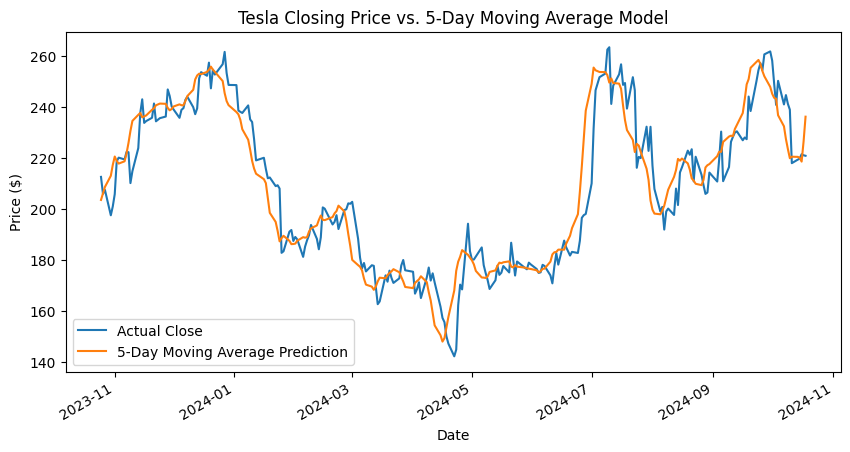

In [98]:
# Plot actual vs. 5-day moving average predictions
df[['Close', 'PRED']].plot(figsize=(10,5))

plt.title('Tesla Closing Price vs. 5-Day Moving Average Model')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend(['Actual Close', '5-Day Moving Average Prediction'])
plt.show()